# NB17 — DST & Foundation Forecasting Exploration

Exploratory notebook focused on daylight saving time (DST) irregularities,
temporal edge cases and possible future directions using foundation forecasting models.

The notebook does not aim to build a production-ready transformer pipeline,
but to explore forecasting robustness challenges that may emerge in real-world
energy and time-sensitive forecasting systems.

# Business Context

In some energy forecasting and billing systems, daylight saving time transitions
can generate irregular temporal windows:

- 23-hour days
- 25-hour days
- duplicated timestamps
- missing timestamps

These irregularities may affect:

- billing calculations
- aggregation logic
- rolling statistics
- lag features
- temporal consistency
- forecasting reliability

This notebook explores these edge cases from an ML engineering perspective.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Synthetic Hourly Dataset

In [4]:
date_range = pd.date_range(
    start="2024-10-26 00:00",
    end="2024-10-28 23:00",
    freq="h"
)

df = pd.DataFrame({
    "timestamp": date_range,
})

df["energy_consumption"] = (
    100
    + 10 * np.sin(np.arange(len(df)) / 24 * 2 * np.pi)
    + np.random.normal(0, 2, len(df))
)

df.head()

,timestamp,energy_consumption
0,2024-10-26 00:00:00,97.826522
1,2024-10-26 01:00:00,101.087240
2,2024-10-26 02:00:00,102.544570
3,2024-10-26 03:00:00,107.998308
4,2024-10-26 04:00:00,108.979929


# Simulating DST Irregularities

DST transitions may create:
- missing timestamps (23-hour day)
- duplicated timestamps (25-hour day)

The following examples simulate these irregularities.

In [5]:
df_missing = df.copy()

df_missing = df_missing[
    df_missing["timestamp"] != "2024-10-27 02:00:00"
]

print("Rows after missing hour simulation:", len(df_missing))

Rows after missing hour simulation: 71


In [6]:
duplicate_row = df[
    df["timestamp"] == "2024-10-27 02:00:00"
]

df_duplicated = pd.concat(
    [df, duplicate_row],
    ignore_index=True
).sort_values("timestamp")

print("Rows after duplicated hour simulation:", len(df_duplicated))

Rows after duplicated hour simulation: 73


# Rolling Statistics Instability

Classical forecasting pipelines often rely on:
- lag features
- rolling averages
- temporal aggregation

DST irregularities may introduce instability into these calculations.

In [7]:
df_missing = df_missing.set_index("timestamp")

df_missing["rolling_mean_24"] = (
    df_missing["energy_consumption"]
    .rolling(24)
    .mean()
)

df_missing[["energy_consumption", "rolling_mean_24"]].tail(10)

,energy_consumption,rolling_mean_24
timestamp,,
2024-10-28 14:00:00,92.471223,99.213947
2024-10-28 15:00:00,92.912448,99.226781
2024-10-28 16:00:00,90.438795,99.120105
2024-10-28 17:00:00,93.297609,99.302604
2024-10-28 18:00:00,90.745663,99.384157
2024-10-28 19:00:00,88.903759,99.392616
2024-10-28 20:00:00,91.817322,99.375918
2024-10-28 21:00:00,95.172936,99.303152
2024-10-28 22:00:00,98.135857,99.499964


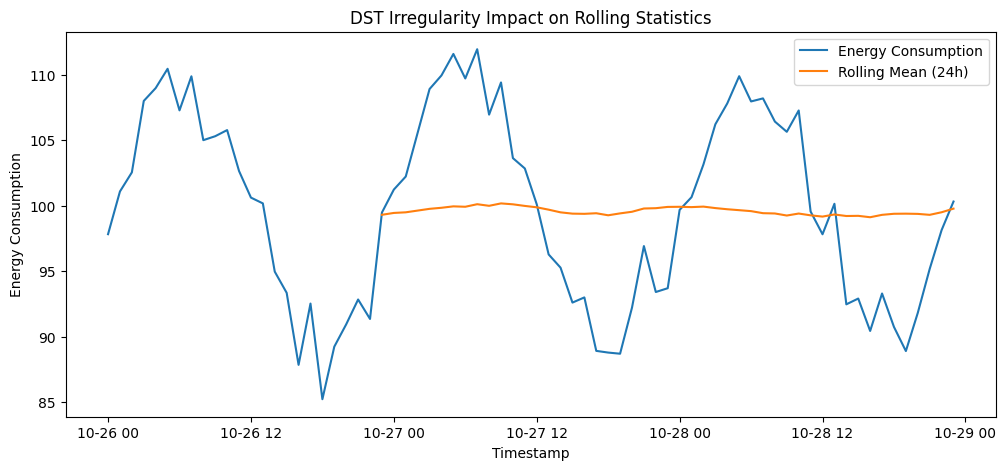

In [9]:
plt.figure(figsize=(12, 5))

plt.plot(
    df_missing.index,
    df_missing["energy_consumption"],
    label="Energy Consumption"
)

plt.plot(
    df_missing.index,
    df_missing["rolling_mean_24"],
    label="Rolling Mean (24h)"
)

plt.title("DST Irregularity Impact on Rolling Statistics")
plt.xlabel("Timestamp")
plt.ylabel("Energy Consumption")

plt.legend()
plt.show()

# Why Classical Forecasting Pipelines May Struggle

Traditional forecasting pipelines often assume:

- regular temporal spacing
- stable rolling windows
- deterministic lag structures

DST transitions may violate these assumptions.

Potential consequences include:

- unstable rolling features
- inconsistent lag alignment
- aggregation mismatches
- forecasting degradation
- billing inconsistencies

# Foundation Forecasting Models

Recent forecasting foundation models such as:

- Chronos
- Moirai
- transformer-based forecasting systems

aim to improve robustness across heterogeneous time-series scenarios.

Potential advantages include:

- probabilistic forecasting
- improved temporal representation learning
- multi-domain pretraining
- robustness to irregular temporal patterns

These models may become increasingly relevant for complex forecasting systems
where temporal irregularities and operational edge cases are common.

# Final Engineering Considerations

This notebook explored DST-related temporal irregularities from an ML engineering perspective.

Key takeaways:

- forecasting systems should validate temporal consistency explicitly
- DST transitions may affect both feature engineering and business logic
- UTC normalization may reduce ambiguity in some systems
- local business time may still remain operationally necessary
- monitoring temporal edge cases is important in production forecasting pipelines

Future experimentation may include:

- Chronos
- Moirai 2.0
- transformer-based forecasting
- probabilistic forecasting
- DST-aware benchmarking pipelines